# Regularization in Language Modeling — Visual Demo (Bigram MLE vs Smoothed)



## 1) Tiny corpus & tokenization

In [1]:
import re, random, math, numpy as np, matplotlib.pyplot as plt
random.seed(0)

text = (
    "the quick brown fox jumps over the lazy dog. "
    "the quick brown fox was very quick. "
    "the dog was not amused by the fox. "
    "a fast fox outruns a slow hound. "
    "dogs and foxes rarely share a den. "
    "the fast dog chases the quick fox. "
    "the fox is sly and the dog is loyal. "
)

def tokenize(s):
    s = s.lower()
    tokens = re.findall(r"[a-z']+|[.!?]", s)
    return ['<BOS>'] + tokens + ['<EOS>']

tokens = tokenize(text)
N = len(tokens)
split = int(0.7*N)
train_tokens = tokens[:split]
val_tokens   = tokens[split-1:]  # overlap 1 token so bigram boundaries exist

vocab = sorted(list(set(tokens)))
V = len(vocab)
tok2id = {t:i for i,t in enumerate(vocab)}

def bigrams(seq):
    return list(zip(seq[:-1], seq[1:]))

train_bi = bigrams(train_tokens)
val_bi   = bigrams(val_tokens)
len(train_tokens), len(val_tokens), V

(44, 20, 31)

## 2) Fit bigram models: MLE (α=0) vs Laplace smoothing (α>0) — safe perplexity

In [2]:
from collections import defaultdict

def fit_counts(bis):
    ctx_tot = defaultdict(int)
    ctx_next = defaultdict(lambda: defaultdict(int))
    for x,y in bis:
        ctx_tot[x]+=1
        ctx_next[x][y]+=1
    return ctx_tot, ctx_next

ctx_tot_tr, ctx_next_tr = fit_counts(train_bi)

def prob_next(y, x, alpha=0.0):
    c_xy = ctx_next_tr[x].get(y, 0)
    c_x  = ctx_tot_tr.get(x, 0)
    if alpha == 0.0:
        if c_x == 0:
            return 0.0
        return c_xy / c_x
    else:
        return (c_xy + alpha) / (c_x + alpha*V)

def seq_logprob_and_zeros(bis, alpha=0.0):
    logp = 0.0
    zeros = 0
    for x,y in bis:
        p = prob_next(y, x, alpha)
        if p == 0.0:
            zeros += 1
        else:
            logp += math.log(p)
    return logp, zeros

def perplexity(bis, alpha=0.0):
    logp, zeros = seq_logprob_and_zeros(bis, alpha)
    n = max(1, len(bis))
    if zeros > 0:
        return float('inf'), zeros
    nll = -logp / n
    # Avoid overflow in exp; beyond ~709 in double precision explodes
    if nll > 700:
        return float('inf'), zeros
    return math.exp(nll), zeros

pp_train_mle, zeros_train_mle = perplexity(train_bi, alpha=0.0)
pp_val_mle,  zeros_val_mle  = perplexity(val_bi,   alpha=0.0)
pp_train_sm,  zeros_train_sm = perplexity(train_bi, alpha=0.2)
pp_val_sm,   zeros_val_sm   = perplexity(val_bi,   alpha=0.2)

print({'V':V,
       'train_perplexity_MLE': pp_train_mle, 'train_zeros_MLE': zeros_train_mle,
       'val_perplexity_MLE':   pp_val_mle,   'val_zeros_MLE': zeros_val_mle,
       'train_perplexity_smooth(alpha=0.2)': pp_train_sm, 'train_zeros_smooth': zeros_train_sm,
       'val_perplexity_smooth(alpha=0.2)':   pp_val_sm,   'val_zeros_smooth': zeros_val_sm})

{'V': 31, 'train_perplexity_MLE': 1.761409793586623, 'train_zeros_MLE': 0, 'val_perplexity_MLE': inf, 'val_zeros_MLE': 13, 'train_perplexity_smooth(alpha=0.2)': 6.344049240721642, 'train_zeros_smooth': 0, 'val_perplexity_smooth(alpha=0.2)': 22.06322316317159, 'val_zeros_smooth': 0}


V = vocabulary size, Perplexity: exp(-average log probability) for a split; lower is better. If the model gives zero probability to any bigram in that split, perplexity is ∞.
*_MLE items: metrics for the unsmoothed bigram model (α = 0, i.e., no regularization).
*_smooth(alpha=0.2) items: metrics for the Laplace/Lidstone-smoothed model (α = 0.2, i.e., regularized).

What you should conclude
If val_zeros_MLE > 0 → the MLE model assigns hard zeros to unseen bigrams → val perplexity = ∞.
With smoothing (α=0.2), zero-prob events disappear, val perplexity becomes finite, and generalization improves.

## 3) Visual — P(next | 'the') bars (top words)

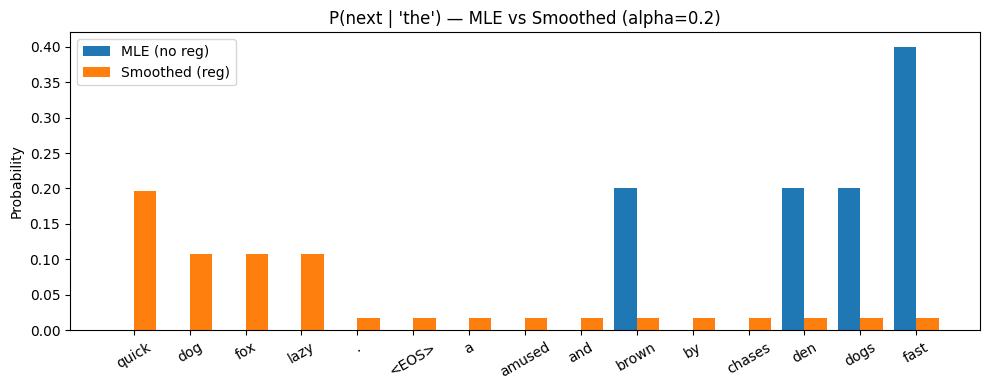

In [3]:
ctx = 'the' if 'the' in vocab else 'a'
probs_mle = []
probs_sm  = []
for w in vocab:
    if w in ['<BOS>']:
        continue
    probs_mle.append((w, prob_next(w, ctx, alpha=0.0)))
    probs_sm.append((w, prob_next(w, ctx, alpha=0.2)))

probs_sm.sort(key=lambda x: x[1], reverse=True)
top = [w for w,_ in probs_sm[:15]]
mle_top = [p for w,p in probs_mle if w in top]
sm_top  = [p for w,p in probs_sm if w in top]

import matplotlib.pyplot as plt
x = np.arange(len(top))
plt.figure(figsize=(10,4))
plt.title(f"P(next | '{ctx}') — MLE vs Smoothed (alpha=0.2)")
plt.bar(x-0.2, mle_top, width=0.4, label='MLE (no reg)')
plt.bar(x+0.2, sm_top,  width=0.4, label='Smoothed (reg)')
plt.xticks(x, top, rotation=30)
plt.ylabel('Probability')
plt.legend(); plt.tight_layout(); plt.show()

What you can see: smoothing redistributes a little probability mass to every possible next token (including ones never seen). By contrast, without smooting, only a few tokesn get a probability (and the others get 0)

## 4) Sweep α — Perplexity and zero-prob counts

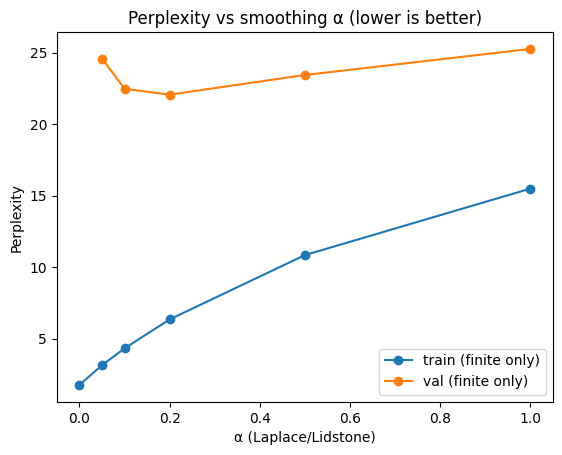

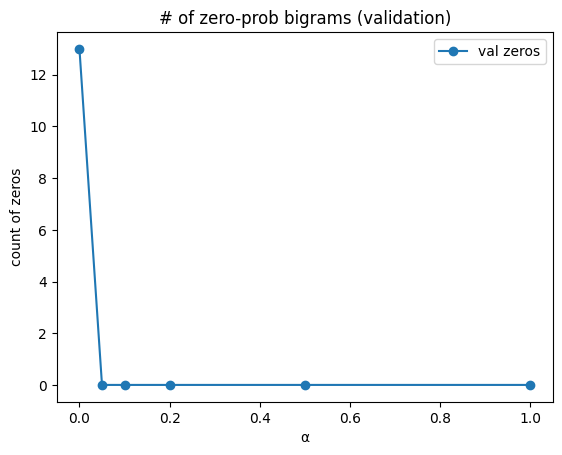

In [4]:
alphas = [0.0, 0.05, 0.1, 0.2, 0.5, 1.0]
pp_tr, pp_va = [], []
zeros_tr, zeros_va = [], []
for a in alphas:
    tr, ztr = perplexity(train_bi, a)
    va, zva = perplexity(val_bi, a)
    pp_tr.append(tr); pp_va.append(va)
    zeros_tr.append(ztr); zeros_va.append(zva)

pp_tr_plot = [np.nan if np.isinf(x) else x for x in pp_tr]
pp_va_plot = [np.nan if np.isinf(x) else x for x in pp_va]

plt.figure()
plt.title('Perplexity vs smoothing α (lower is better)')
plt.plot(alphas, pp_tr_plot, marker='o', label='train (finite only)')
plt.plot(alphas, pp_va_plot, marker='o', label='val (finite only)')
plt.xlabel('α (Laplace/Lidstone)')
plt.ylabel('Perplexity')
plt.legend(); plt.show()

plt.figure()
plt.title('# of zero-prob bigrams (validation)')
plt.plot(alphas, zeros_va, marker='o', label='val zeros')
plt.xlabel('α'); plt.ylabel('count of zeros'); plt.legend(); plt.show()

What you should see: on training, the perplexity (lower is better) goes up when you increase alpha, so lower alpha sounds better. But in validation, the number of bigrams with zero probability is high with alpha=0, then drops when a sweet spot value is found. So alpha should be small, but not null.

## 5) Sample generations (intuition)

In [5]:
def sample_bigram(alpha=0.0, max_len=20):
    cur = '<BOS>'
    out = []
    for _ in range(max_len):
        ps = np.array([prob_next(w, cur, alpha) for w in vocab])
        if ps.sum() == 0:
            # if MLE assigns zero across the board (unseen context), fall back to uniform
            ps = np.ones(len(vocab)) / len(vocab)
        else:
            ps = ps / ps.sum()
        w = random.choices(vocab, weights=ps, k=1)[0]
        out.append(w)
        cur = w
        if w == '<EOS>':
            break
    return ' '.join(out)

print('MLE   :', sample_bigram(alpha=0.0))
print('Smooth:', sample_bigram(alpha=0.2))

MLE   : the quick brown fox outruns a slow hound . the quick brown fox was very quick brown fox was very
Smooth: dogs outruns sly outruns dogs a fast is the very jumps slow den quick dog . slow foxes rarely rarely


What you see: when running the cell several times, the MLE version tends to break, with a weird jump or an early <EOS>. This is because only some tokesn get a positive probability, and many onlyget 0 probability. By contrast with smooting, more tokens get a small probability, so the sentences are... well, smoother.